# Per-Sensor QE Correction Optimization (Multi-Source)

This notebook optimizes per-sensor quantum efficiency (QE) corrections using gradient descent with multiple isotropic source positions.

In [1]:
import sys
sys.path.append('../')

from tools.geometry import generate_detector
from tools.losses import WC_loss
from tools.simulation import setup_event_simulator
from tools.detector_params import (
    DetectorParams, isotropic_source,
    save_detector_params, load_detector_params,
)
import jax
import jax.numpy as jnp
from jax import value_and_grad, jit
import optax
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from pathlib import Path
import time

In [2]:
default_json_filename = '../config/SK_geom_config.json'
detector = generate_detector(default_json_filename)
detector_points = jnp.array(detector.all_points)
NUM_DETECTORS = len(detector_points)

Nphot = 8_000_000
K = 9
Nphot_True = 15_000_000
K_True = 12

In [3]:
np.random.seed(42)
true_qe = 0.2
true_qe_corrections = jnp.array(np.random.normal(1.0, 0.1, NUM_DETECTORS))

# Load base from config and replace with synthetic values
base_params = load_detector_params('../config/SK_physics_config.json')
if base_params.qe_corrections.ndim == 0:
    base_params = base_params._replace(
        qe_corrections=jnp.ones(NUM_DETECTORS) * base_params.qe_corrections
    )
TRUE_PARAMS = base_params._replace(
    wall_reflection_rate=jnp.array(0.1),
    sensor_reflection_rate=jnp.array(0.3),
    qe_corrections=true_qe_corrections,
)

print(f"True base QE: {true_qe}")
print(f"QE corrections - mean: {float(jnp.mean(true_qe_corrections)):.3f}, std: {float(jnp.std(true_qe_corrections)):.3f}")

True base QE: 0.2
QE corrections - mean: 1.000, std: 0.100


In [4]:
simulate_event = setup_event_simulator(
    default_json_filename, Nphot, temperature=None, K=K,
    is_data=False, is_calibration=True
)
simulate_data = setup_event_simulator(
    default_json_filename, Nphot_True, temperature=None, K=K_True,
    is_data=False, is_calibration=True,
    default_detector_params=TRUE_PARAMS,
)

In [5]:
xy_positions = [(-10, 0), (10, 0), (0, 0), (0, -10), (0, 10)]
z_positions = [-10, 0, 10]
source_intensity = 100_000_000

# Create IsotropicSource instances (callable pytrees)
all_sources = []
for x, y in xy_positions:
    for z in z_positions:
        all_sources.append(isotropic_source(position=[float(x), float(y), float(z)],
                                            intensity=source_intensity))

print(f"Total number of source locations: {len(all_sources)}")

Total number of source locations: 15


In [6]:
print("\nGenerating true data for all source locations...")
all_true_data = []

for i, source in enumerate(tqdm(all_sources, desc="Generating true data")):
    key_data = jax.random.PRNGKey(1000 + i)
    true_data = jax.lax.stop_gradient(simulate_data(source, key_data))
    all_true_data.append(true_data)

del simulate_data  # Free memory


Generating true data for all source locations...


Generating true data: 100%|██████████| 15/15 [00:33<00:00,  2.25s/it]


In [7]:
@jit
def loss_and_grad_fn(qe_corrections, source, true_data, key_used):
    def loss_fn(qe_corr):
        dp = TRUE_PARAMS._replace(qe_corrections=qe_corr)
        simulated_data = simulate_event(source, dp, key_used)
        return WC_loss(
            detector_points, *true_data, *simulated_data,
            lambda_poisson=1.0, lambda_time=0.0
        )
    return value_and_grad(loss_fn)(qe_corrections)

In [8]:
print("Running QE correction gradient descent with multiple sources...")

# Start with qe_corrections = 1.0 (unknown)
qe_corrections = jnp.ones(NUM_DETECTORS)

# Adam with adaptive LR reduction
num_steps = 150
initial_learning_rate = 0.005
patience = 16
factor = 0.7
min_lr = 1e-5
threshold = 1e-5

optimizer = optax.inject_hyperparams(optax.adam)(
    learning_rate=initial_learning_rate, b1=0.9, b2=0.99
)
opt_state = optimizer.init(qe_corrections)

losses = []
source_indices_used = []
best_loss = float('inf')
patience_counter = 0
current_lr = initial_learning_rate

selection_key = jax.random.PRNGKey(999)

for step in tqdm(range(num_steps), desc="Adam optimization steps"):
    # Randomly select a source location
    selection_key, subkey = jax.random.split(selection_key)
    source_idx = int(jax.random.choice(subkey, len(all_sources)))
    source_indices_used.append(source_idx)
    
    source = all_sources[source_idx]
    true_data = all_true_data[source_idx]
    
    key_used = jax.random.PRNGKey(step)
    loss, grads = loss_and_grad_fn(qe_corrections, source, true_data, key_used)
    losses.append(float(loss))
    
    updates, opt_state = optimizer.update(grads, opt_state)
    qe_corrections = optax.apply_updates(qe_corrections, updates)
    
    # Plateau-based LR reduction
    if step >= 5:
        avg_recent_loss = float(jnp.mean(jnp.array(losses[-5:])))
        if avg_recent_loss < best_loss - threshold:
            best_loss = avg_recent_loss
            patience_counter = 0
        else:
            patience_counter += 1
        
        if patience_counter >= patience and current_lr > min_lr:
            current_lr = max(current_lr * factor, min_lr)
            opt_state.hyperparams['learning_rate'] = current_lr
            patience_counter = 0
            print(f"  Reducing LR to {current_lr:.6f} at step {step}")
    
    if step % 10 == 0:
        print(f"  Step {step}: Loss = {float(loss):.6f}, Source idx = {source_idx}, LR = {current_lr:.6f}")

# Reconstruct full params for evaluation
current_params = TRUE_PARAMS._replace(qe_corrections=qe_corrections)

print(f"\nInitial loss: {losses[0]:.6f}")
print(f"Final loss: {losses[-1]:.6f}")
print(f"Final LR: {current_lr:.6f}")

Running QE correction gradient descent with multiple sources...


Adam optimization steps:   1%|          | 1/150 [00:08<21:40,  8.73s/it]

  Step 0: Loss = 0.021072, Source idx = 14, LR = 0.005000


Adam optimization steps:   7%|▋         | 11/150 [00:18<02:20,  1.01s/it]

  Step 10: Loss = 0.020428, Source idx = 8, LR = 0.005000


...

  Step 130: Loss = 0.015724, Source idx = 9, LR = 0.001200


Adam optimization steps:  94%|█████████▍| 141/150 [02:21<00:08,  1.02it/s]

  Step 140: Loss = 0.016659, Source idx = 4, LR = 0.001200


Adam optimization steps: 100%|██████████| 150/150 [02:30<00:00,  1.00s/it]

  Reducing LR to 0.000840 at step 149

Initial loss: 0.021072
Final loss: 0.015723
Final LR: 0.000840


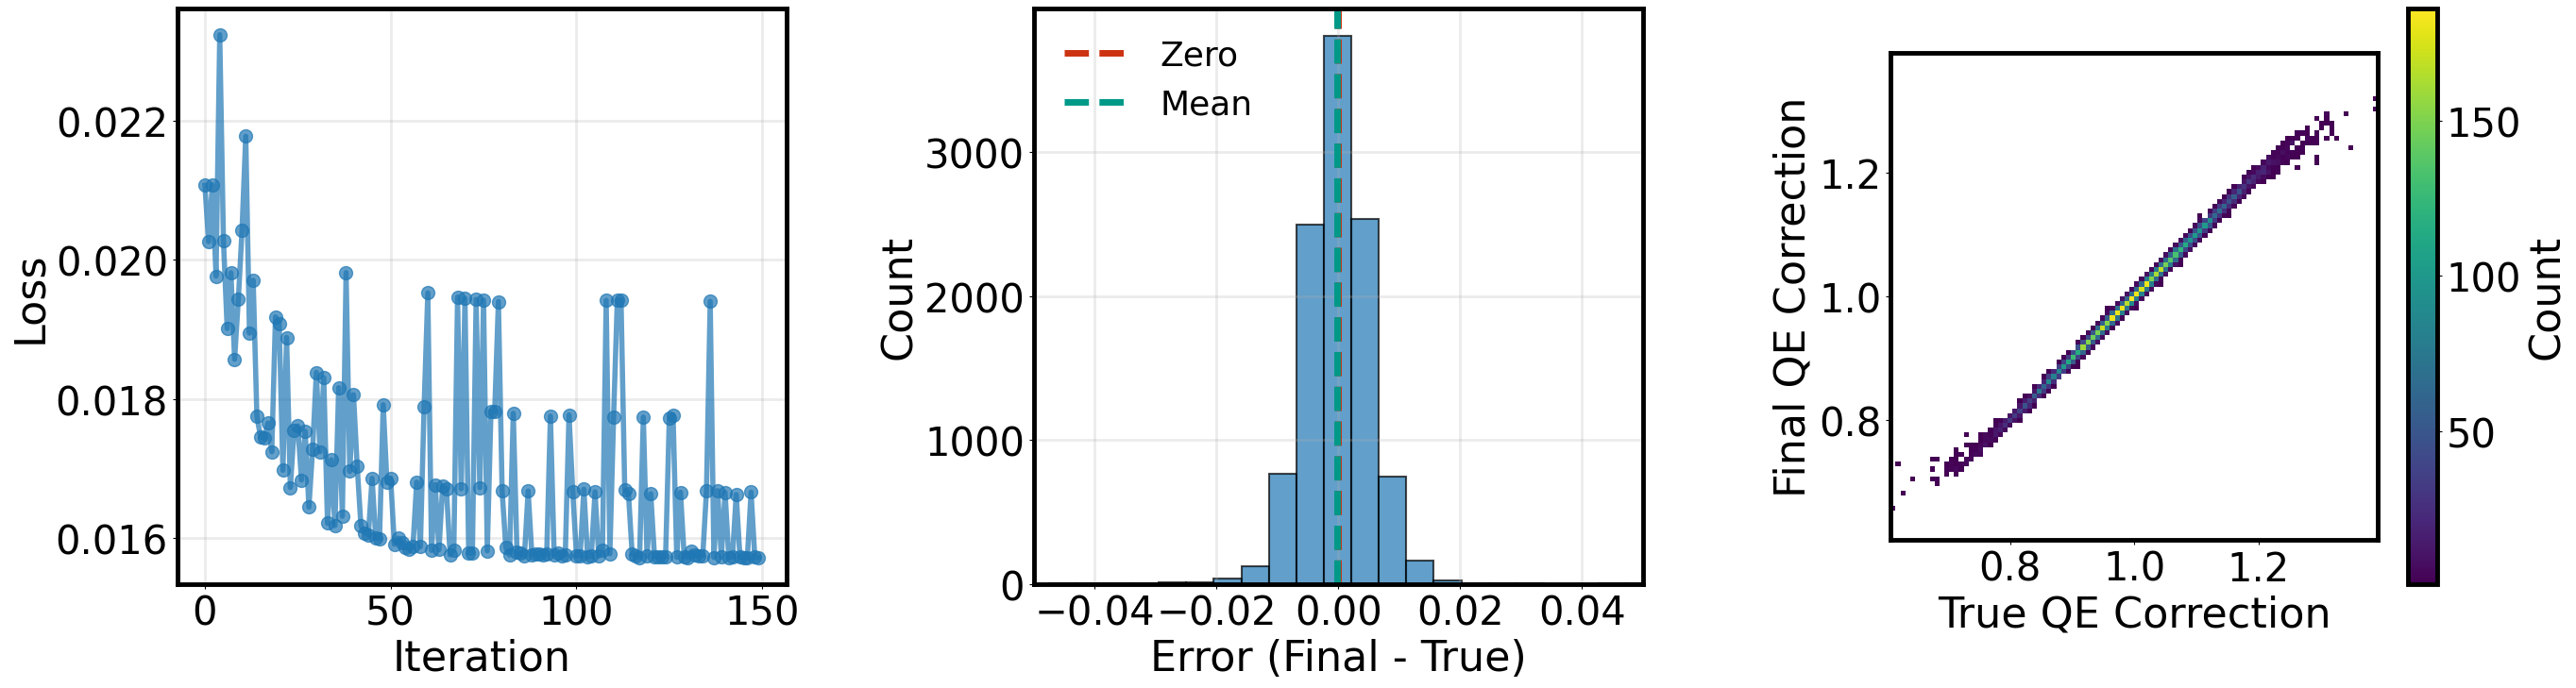


Error Statistics:
  Mean error: -0.000217
  Std error: 0.006180
  RMSE: 0.006184
  Max absolute error: 0.115277


In [9]:
final_qe_corrections = qe_corrections
errors = final_qe_corrections - true_qe_corrections

plt.rcParams.update({
    'font.size': 30, 'axes.labelsize': 32, 'xtick.labelsize': 30,
    'ytick.labelsize': 30, 'legend.fontsize': 26,
    'axes.linewidth': 3.5, 'grid.alpha': 0.3, 'grid.linewidth': 2.0
})

fig, axs = plt.subplots(1, 3, figsize=(28, 8))

# Loss over iterations
axs[0].plot(range(len(losses)), losses, 'o-', linewidth=4, markersize=10, alpha=0.7)
axs[0].set_xlabel('Iteration')
axs[0].set_ylabel('Loss')
axs[0].grid(True, alpha=0.25)

# Error distribution
axs[1].hist(np.array(errors), bins=50, alpha=0.7, edgecolor='black', linewidth=1.5)
axs[1].axvline(x=0, color='#CC3311', linestyle='--', lw=5, label='Zero')
axs[1].axvline(x=float(jnp.mean(errors)), color='#009988', linestyle='--', lw=5, label='Mean')
axs[1].set_xlim([-0.05, 0.05])
axs[1].set_xlabel('Error (Final - True)')
axs[1].set_ylabel('Count')
axs[1].legend(frameon=False, loc='upper left')
axs[1].grid(True, alpha=0.25)

# 2D histogram: true vs final
min_val = min(float(jnp.min(true_qe_corrections)), float(jnp.min(final_qe_corrections)))
max_val = max(float(jnp.max(true_qe_corrections)), float(jnp.max(final_qe_corrections)))
h = axs[2].hist2d(np.array(true_qe_corrections), np.array(final_qe_corrections),
                   bins=100, cmap='viridis', cmin=1, range=[[min_val, max_val], [min_val, max_val]])
axs[2].set_xlabel('True QE Correction')
axs[2].set_ylabel('Final QE Correction')
axs[2].set_aspect('equal')
cbar = plt.colorbar(h[3], ax=axs[2], label='Count')
cbar.ax.tick_params(labelsize=30)
cbar.set_label('Count', fontsize=32)

plt.tight_layout(w_pad=2, h_pad=2)
Path('figures').mkdir(exist_ok=True)
plt.savefig('figures/qe_correction_convergence_multi_source_v2.pdf', format='pdf', bbox_inches='tight', pad_inches=0.3)
plt.savefig('figures/qe_correction_convergence_multi_source_v2.png', dpi=600, bbox_inches='tight', pad_inches=0.3)
plt.show()

print(f"\nError Statistics:")
print(f"  Mean error: {float(jnp.mean(errors)):.6f}")
print(f"  Std error: {float(jnp.std(errors)):.6f}")
print(f"  RMSE: {float(jnp.sqrt(jnp.mean(errors**2))):.6f}")
print(f"  Max absolute error: {float(jnp.max(jnp.abs(errors))):.6f}")

In [10]:
print("Evaluating final model on all source locations...\n")

final_losses_per_source = []
for i, (source, true_data) in enumerate(zip(all_sources, all_true_data)):
    key_eval = jax.random.PRNGKey(5000 + i)
    simulated_data = simulate_event(source, current_params, key_eval)
    loss = WC_loss(detector_points, *true_data, *simulated_data,
                   lambda_poisson=1.0, lambda_time=0.0)
    final_losses_per_source.append(float(loss))
    pos = source.position
    print(f"Source {i+1} [{float(pos[0]):5.1f}, {float(pos[1]):5.1f}, {float(pos[2]):5.1f}]: Loss = {float(loss):.6f}")

print(f"\nMean final loss: {np.mean(final_losses_per_source):.6f}")
print(f"Std of losses: {np.std(final_losses_per_source):.6f}")

Evaluating final model on all source locations...

Source 1 [-10.0,   0.0, -10.0]: Loss = 0.015723
Source 2 [-10.0,   0.0,   0.0]: Loss = 0.016655
Source 3 [-10.0,   0.0,  10.0]: Loss = 0.015772
Source 4 [ 10.0,   0.0, -10.0]: Loss = 0.015761
Source 5 [ 10.0,   0.0,   0.0]: Loss = 0.016657
Source 6 [ 10.0,   0.0,  10.0]: Loss = 0.015738
Source 7 [  0.0,   0.0, -10.0]: Loss = 0.017739
Source 8 [  0.0,   0.0,   0.0]: Loss = 0.019404
Source 9 [  0.0,   0.0,  10.0]: Loss = 0.017766
Source 10 [  0.0, -10.0, -10.0]: Loss = 0.015725
Source 11 [  0.0, -10.0,   0.0]: Loss = 0.016616
Source 12 [  0.0, -10.0,  10.0]: Loss = 0.015713
Source 13 [  0.0,  10.0, -10.0]: Loss = 0.015737
Source 14 [  0.0,  10.0,   0.0]: Loss = 0.016675
Source 15 [  0.0,  10.0,  10.0]: Loss = 0.015805

Mean final loss: 0.016499
Std of losses: 0.001040
